# Modules

In [2]:
import sys, os

mod_dir = os.path.abspath('/Users/rangulo/projects/EtaCar_LEs/python')
sys.path.append(mod_dir)

from LC_utility import *

# Read in data and parameter files

In [4]:
### Read in LC data

## filter g
LCtab_g1 = readin_LCdf('LC_tables/data/LCtable1_g.csv')
LCtab_g2 = readin_LCdf('LC_tables/data/LCtable2_g.csv')
LCtab_g3 = readin_LCdf('LC_tables/data/LCtable3_g.csv')
LCtab_g4 = readin_LCdf('LC_tables/data/LCtable4_g.csv')

## filter r
LCtab_r1 = readin_LCdf('LC_tables/data/LCtable1_r.csv')
LCtab_r2 = readin_LCdf('LC_tables/data/LCtable2_r.csv')
LCtab_r3 = readin_LCdf('LC_tables/data/LCtable3_r.csv')
LCtab_r4 = readin_LCdf('LC_tables/data/LCtable4_r.csv')

## filter i
LCtab_i1 = readin_LCdf('LC_tables/data/LCtable1_i.csv')
LCtab_i2 = readin_LCdf('LC_tables/data/LCtable2_i.csv')
LCtab_i3 = readin_LCdf('LC_tables/data/LCtable3_i.csv')
LCtab_i4 = readin_LCdf('LC_tables/data/LCtable4_i.csv')

## filter z
LCtab_z1 = readin_LCdf('LC_tables/data/LCtable1_z.csv')
LCtab_z2 = readin_LCdf('LC_tables/data/LCtable2_z.csv')
LCtab_z3 = readin_LCdf('LC_tables/data/LCtable3_z.csv')
LCtab_z4 = readin_LCdf('LC_tables/data/LCtable4_z.csv')

In [5]:
### Define flux and error limits

ferr_lim = 1.0            # upper limit of flux error (mJyas2_err)

g_flim = 20.0             # upper limit of flux (mJyas2)
r_flim = 20.0
i_flim = 50.0
z_flim = 50.0


### Some images need to be excluded due to quality
## Images from ccd 54 have bad bands (mainly filter i is affected)
## filter g
badims_a54g = pd.read_csv('txt_files/ec0915a54g_badims.txt', header=None)[0]
bad_expnums_a54g = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54g]

## filter r
bad_expnums_a54r = None

## filter i
badims_a54i = pd.read_csv('txt_files/ec0915a54i_badims.txt', header=None)[0]
bad_expnums_a54i = [float(re.search('\.(\d+)_ooi_',os.path.basename(im)).groups()[0]) for im in badims_a54i]

## filter z
bad_expnums_a54z = None


## filter g
flag_inds(LCtab_g1, f_lm=g_flim, ferr_lm=ferr_lim, bad_expnums=None)
flag_inds(LCtab_g2, f_lm=g_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g)
flag_inds(LCtab_g3, f_lm=g_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g)
flag_inds(LCtab_g4, f_lm=g_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54g)

## filter r
flag_inds(LCtab_r1, f_lm=r_flim, ferr_lm=ferr_lim, bad_expnums=None)
flag_inds(LCtab_r2, f_lm=r_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54r)
flag_inds(LCtab_r3, f_lm=r_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54r)
flag_inds(LCtab_r4, f_lm=r_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54r)

## filter i
flag_inds(LCtab_i1, f_lm=i_flim, ferr_lm=ferr_lim, bad_expnums=None)
flag_inds(LCtab_i2, f_lm=i_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i)
flag_inds(LCtab_i3, f_lm=i_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i)
flag_inds(LCtab_i4, f_lm=i_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54i)

## filter z
flag_inds(LCtab_z1, f_lm=z_flim, ferr_lm=ferr_lim, bad_expnums=None)
flag_inds(LCtab_z2, f_lm=z_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54z)
flag_inds(LCtab_z3, f_lm=z_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54z)
flag_inds(LCtab_z4, f_lm=z_flim, ferr_lm=ferr_lim, bad_expnums=bad_expnums_a54z)

'Updated LC dataframe -- flagged working indices'

In [6]:
### Fit parmeters of LC
## lc_id, t shift, a-norm, b-offset

## filter g
gparms1 = pd.read_csv('LC_tables/fit_params/f2params_g1.csv').values
gparms2 = pd.read_csv('LC_tables/fit_params/f2params_g2.csv').values
gparms3 = pd.read_csv('LC_tables/fit_params/f2params_g3.csv').values
gparms4 = pd.read_csv('LC_tables/fit_params/f2params_g4.csv').values

## filter r
rparms1 = pd.read_csv('LC_tables/fit_params/f2params_r1.csv').values
rparms2 = pd.read_csv('LC_tables/fit_params/f2params_r2.csv').values
rparms3 = pd.read_csv('LC_tables/fit_params/f2params_r3.csv').values
rparms4 = pd.read_csv('LC_tables/fit_params/f2params_r4.csv').values

## filter i
iparms1 = pd.read_csv('LC_tables/fit_params/f2params_i1.csv').values
iparms2 = pd.read_csv('LC_tables/fit_params/f2params_i2.csv').values
iparms3 = pd.read_csv('LC_tables/fit_params/f2params_i3.csv').values
iparms4 = pd.read_csv('LC_tables/fit_params/f2params_i4.csv').values

## filter z
zparms1 = pd.read_csv('LC_tables/fit_params/f2params_z1.csv').values
zparms2 = pd.read_csv('LC_tables/fit_params/f2params_z2.csv').values
zparms3 = pd.read_csv('LC_tables/fit_params/f2params_z3.csv').values
zparms4 = pd.read_csv('LC_tables/fit_params/f2params_z4.csv').values

In [7]:
gparms1[2]

array([0.17858345, 0.22972871, 0.28965195, 0.26505068, 0.20237813,
       0.3790511 ])

# Check Normalization

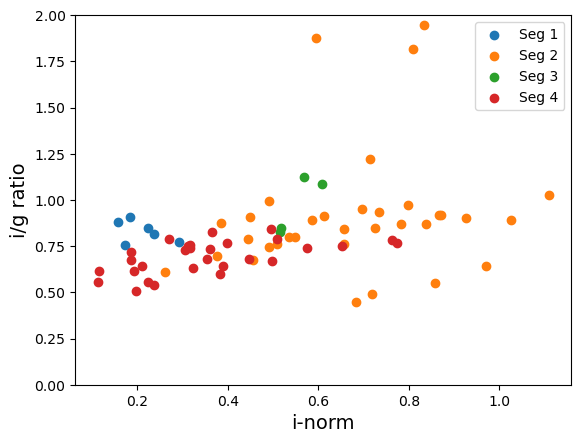

In [37]:
plt.scatter(iparms1[2], iparms1[2]/gparms1[2], label='Seg 1')
plt.scatter(iparms2[2], iparms2[2]/gparms2[2], label='Seg 2')
plt.scatter(iparms3[2], iparms3[2]/gparms3[2], label='Seg 3')
plt.scatter(iparms4[2], iparms4[2]/gparms4[2], label='Seg 4')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/g ratio', fontsize=14)
plt.legend()
plt.show()

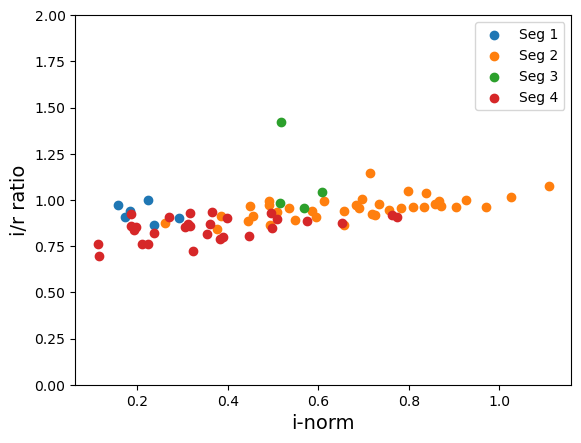

In [34]:
plt.scatter(iparms1[2], iparms1[2]/rparms1[2], label='Seg 1')
plt.scatter(iparms2[2], iparms2[2]/rparms2[2], label='Seg 2')
plt.scatter(iparms3[2], iparms3[2]/rparms3[2], label='Seg 3')
plt.scatter(iparms4[2], iparms4[2]/rparms4[2], label='Seg 4')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/r ratio', fontsize=14)
plt.legend()
plt.show()

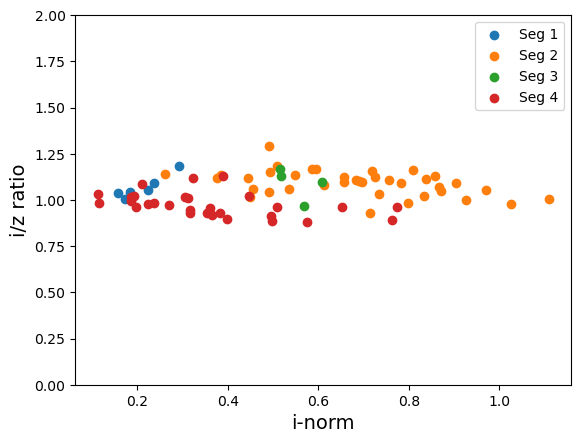

In [31]:
plt.scatter(iparms1[2], iparms1[2]/zparms1[2], label='Seg 1')
plt.scatter(iparms2[2], iparms2[2]/zparms2[2], label='Seg 2')
plt.scatter(iparms3[2], iparms3[2]/zparms3[2], label='Seg 3')
plt.scatter(iparms4[2], iparms4[2]/zparms4[2], label='Seg 4')

plt.ylim(0,2)
plt.xlabel('i-norm', fontsize=14)
plt.ylabel('i/z ratio', fontsize=14)
plt.legend()
plt.show()